In [1]:
import numpy as np
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from utils import *
from plot import *

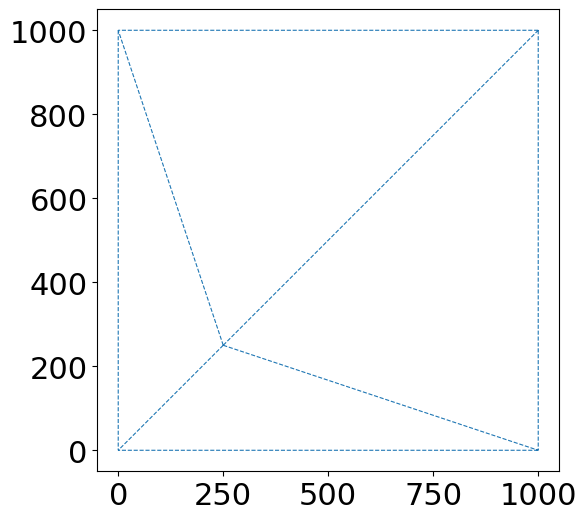

In [2]:
# --- 1. Définition des points (nœuds) ---
points = np.array([
    [0.0, 0.0],  # nœud 0
    [1000.0, 0.0],  # nœud 1
    [0.0, 1000.0],  # nœud 2
    [1000.0, 1000.0],  # nœud 3
    [250.0, 250.0]   # nœud 4 (au centre)
])

# --- 2. Définition des triangles (connectivité) ---
conn = np.array([
    [0, 1, 4],  # triangle 0
    [4, 1, 3],  # triangle 1
    [3, 2, 4],  # triangle 2
    [4, 2, 0]   # triangle 3
])

# --- 3. Affichage du maillage ---
plotMesh(points, conn)

In [3]:
def calculerD(contraintes_planes=True):
    
    E = 210e3 # 210GPa = 210e9 N/m^2 = 210e3 N/mm^2
    nu = 0.3    

    # On fait des contraintes planes par défaut
    if contraintes_planes:
        D = (E/(1-nu**2))* np.array(
            [[1,  nu, 0],
             [nu, 1,  0],
             [0,  0,  (1-nu)/2]])
    else:
        raise RuntimeError('Déformations planes à implémenter!')
    return D

In [4]:
# Coord iso, définitions des fonctions N et propriétés

import sympy as sp

# 1. Définir les variables naturelles
s, t = sp.symbols('s t')

# 2. Définir les fonctions de forme N1, N2, N3 avec lambdas
N1 = lambda s, t: 1 - s - t
N2 = lambda s, t: s
N3 = lambda s, t: t

# 3. Définir aussi symboliquement pour vérification
N1_sym = 1 - s - t
N2_sym = s
N3_sym = t

# 4. Vérifier que la somme est toujours 1
somme_N = sp.simplify(N1_sym + N2_sym + N3_sym)
print("Somme N1+N2+N3:", somme_N)
assert somme_N == 1, "Erreur: La somme des Ni n'est pas 1"

# 5. Vérification propriété delta_ij :
# Points de référence du triangle de référence
points_ref = [
    (0, 0),  # sommet 0
    (1, 0),  # sommet 1
    (0, 1)   # sommet 2
]

# Matrice pour vérifier Ni(xj)
delta_check = []
for i, N_sym in enumerate([N1_sym, N2_sym, N3_sym]):
    row = []
    for (sj, tj) in points_ref:
        val = N_sym.subs({s: sj, t: tj})
        row.append(val)
    delta_check.append(row)

# Affichage
print("\nMatrice Ni(xj) :")
for row in delta_check:
    print(row)

# Assertions pour propriété de Kronecker delta
for i in range(3):
    for j in range(3):
        expected = 1 if i == j else 0
        assert delta_check[i][j] == expected, f"Erreur propriété delta_ij en ({i},{j})"

print("\n✅ Toutes vérifications symboliques réussies!")


Somme N1+N2+N3: 1

Matrice Ni(xj) :
[1, 0, 0]
[0, 1, 0]
[0, 0, 1]

✅ Toutes vérifications symboliques réussies!


In [5]:
def calculerC():
    N1s, N1t = [-1, -1]
    N2s, N2t = [1, 0]
    N3s, N3t = [0, 1]
    C = np.array([
        [N1s, 0, N2s, 0, N3s, 0],
        [N1t, 0, N2t, 0, N3t, 0],
        [0, N1s, 0, N2s, 0, N3s],
        [0, N1t, 0, N2t, 0, N3t]])
    return C

In [6]:
def calculerBetJ(x, noeuds):
    C = calculerC()

    grads = C@noeuds.ravel()
    J = np.array([[grads[0], grads[2]],
                  [grads[1], grads[3]]])
    
    
    # Définition de A
    A = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 1, 0]
    ])

    # Définition de la matrice contenant les Jacobiennes
    Jblock = np.zeros((4, 4))
    Jblock[:2, :2] = J
    Jblock[2:, 2:] = J
    
    Mat_J = np.linalg.inv(Jblock)
    B = A@Mat_J@C
    return B, J

In [7]:
def calculerMatriceRigiditeLocale(connectivite_element, coordonnees):
    
    quads = [[1/3, 1/3]]
    weights = [1/2]     # C et J d'ordre 0 -> B d'ordre 0 -> BDB d'ordre 0 -> 1 pts de quadrature (0 <= 2*1-1 = 1)
    
    noeuds = coordonnees[connectivite_element.ravel(), :] # les noeuds de l'élément traité
    K_local = np.zeros((6, 6)) # 6x6 for T3 only
    
    for x_q, w_q in zip(quads, weights):
        B, J = calculerBetJ(x_q, noeuds)  # calcule B et J sur le point de quadrature x_q
        detJ = np.linalg.det(J)           # calcule det(J) pour l'intégration
        D = calculerD()                   # calcule la loi de constitution D
           
        # somme la quadrature avec le poid w_q
        K_local = K_local + w_q * B.T@D@B * detJ
        
    # l'épaisseur, on peut changer svv, j ai juste repris la valeur de la serie 
    t = 10. # mm
    
    return t*K_local

In [8]:
def calculerNumerosEquations(connectivite):

    n_elem  = connectivite.shape[0]
    n_nodes_per_elem = connectivite.shape[1]
    numEq = np.zeros((n_elem, 2*n_nodes_per_elem), dtype=int)
    for e in range(n_elem):
        for i in range(n_nodes_per_elem):
            numEq[e, 2*i]   = 2*connectivite[e, i];
            numEq[e, 2*i+1] = 2*connectivite[e, i]+1;
    return numEq

def assemblerMatriceRigidite(connectivite, coordonnees):

    n_elem  = connectivite.shape[0]
    n_nodes = coordonnees.shape[0]
    numEq = calculerNumerosEquations(connectivite)

    K = np.zeros((n_nodes*2, n_nodes*2))
    for e in range(n_elem):
        # On récupère les degrés de liberté de l'élément e
        ddl = numEq[e, :]
        # On récupère les noeuds de l'élément e
        connectivite_element = connectivite[e, :]
        # On calcule la matrice de rigidite locale de l'élément e
        K_locale = calculerMatriceRigiditeLocale(connectivite_element, coordonnees)
        # On assemble
        for i, gi in enumerate(ddl):
            for j, gj in enumerate(ddl):
                K[gi, gj] += K_locale[i, j]
    return K

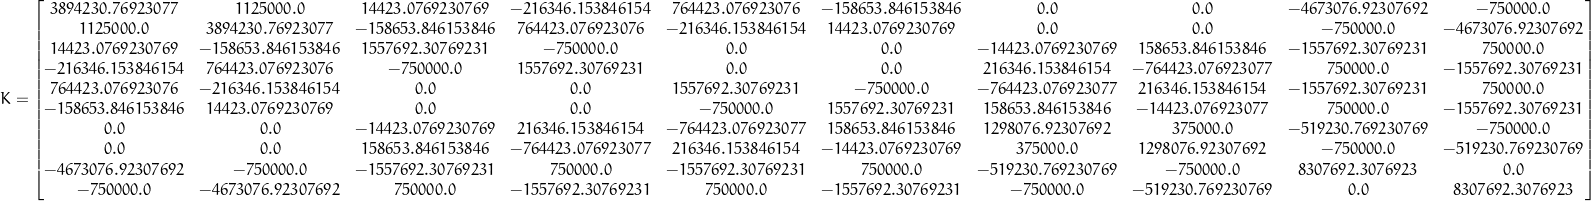

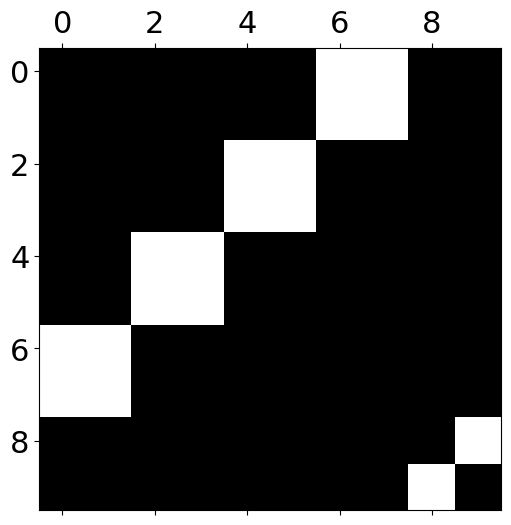

In [9]:
K = assemblerMatriceRigidite(conn, points)
plot_matrix(K, 'K')
plt.spy(K)

In [10]:
def calculerFtraction(nodes):
    """
    Applique +100 N (traction verticale) sur chaque nœud où y == 1000.0.
    """
    n_nodes = nodes.shape[0]
    F = np.zeros((n_nodes, 2), dtype=float)

    for index, node in enumerate(nodes):
        if node[1] == 1000.0:
            F[index, 1] = 100

    return F.ravel()

F = calculerFtraction(points)

In [11]:
def calculerBlocages(nodes):
    n_nodes = nodes.shape[0]
    blocages = np.zeros((n_nodes, 2), dtype=bool)

    for index, (x, y) in enumerate(nodes):
        if y == 0:
            blocages[index, 1] = True
        if x == 0:
            blocages[index, 0] = True

    return blocages.ravel()

blocages = calculerBlocages(points)
libres = np.logical_not(blocages)
libres


array([False, False,  True, False, False,  True,  True,  True,  True,
        True])

[[ 0.00000000e+00  0.00000000e+00]
 [-2.85714286e-05  0.00000000e+00]
 [ 0.00000000e+00  9.52380952e-05]
 [-2.85714286e-05  9.52380952e-05]
 [-7.14285714e-06  2.38095238e-05]]


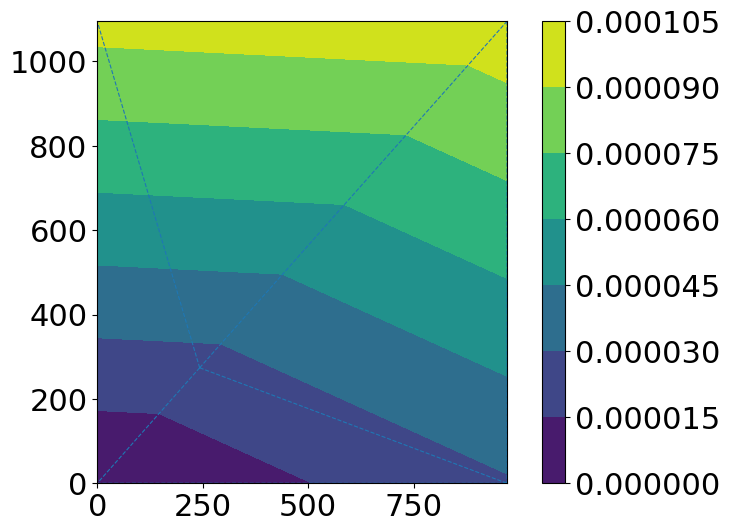

In [12]:
# --- Résolution du système Ku = F avec conditions aux limites ---
n_nodes = points.shape[0]

# Initialisation du vecteur de déplacements
u = np.zeros(n_nodes * 2)

# Résolution uniquement sur les ddl libres
u[libres] = np.linalg.solve(K[libres, :][:, libres], F[libres])


plotMesh(points + u.reshape(n_nodes, 2) * 1000000, conn, u)
print(u.ravel().reshape((-1,2)))

In [13]:
# --- Calcul et affichage de la déformation globale epsilon ---

# 1. Trouver le déplacement moyen vertical en haut (y=1)
u_reshaped = u.reshape((n_nodes, 2))  # (n_nodes, 2) : déplacement (ux, uy)

# 2. Identifier les noeuds situés en haut (où y=1)
nodes_haut = np.where(points[:,1] == 1000.0)[0]

# 3. Prendre les déplacements verticaux u_y de ces noeuds
deplacements_haut = u_reshaped[nodes_haut, 1]  # composante verticale seulement

# 4. Calculer déplacement moyen vertical en haut
deplacement_moyen = np.mean(deplacements_haut)

# 5. Hauteur initiale L
L = np.max(points[:,1]) - np.min(points[:,1])  # différence y max - y min
# Attention : si unités douteuses (m ou mm) on reste cohérent

# 6. Déformation epsilon
epsilon = deplacement_moyen / L

# 7. Affichage
print(f"Déformation moyenne epsilon = {epsilon:.6e} (adimensionnel)")
print(f"Déplacement moyen en haut = {deplacement_moyen:.6e} mm")
print(f"Hauteur initiale L = {L:.6e} mm")


Déformation moyenne epsilon = 9.523810e-08 (adimensionnel)
Déplacement moyen en haut = 9.523810e-05 mm
Hauteur initiale L = 1.000000e+03 mm


In [14]:
valeur_exacte = 0.02/210000 # (F/A)/E = (200/(10*1000))/E = 0.02/210000 <- N/mm2 for both
print(valeur_exacte)

a = np.abs(valeur_exacte-epsilon)
EcartRelatif = a/(valeur_exacte)
print(EcartRelatif)

if EcartRelatif < 1e-14:
    print("La solution est correcte")
else:
    print("La solution n'est pas correcte")

9.523809523809524e-08
4.1689902872672595e-16
La solution est correcte


In [15]:
#Essai de cisaillement sur maillage initial
def calculerBlocagesshear(points):
    n_nodes = points.shape[0]
    blocages = np.zeros((n_nodes, 2), dtype=bool)

    for i, (x, y) in enumerate(points):
        if y == 0.0:  
            blocages[i, :] = True  # blocage bas
        if y == 1000.0:
            blocages[i, 1] = True  # blocage haut

    return blocages.ravel()

blocages_shear = calculerBlocagesshear(points)
libres2 = np.logical_not(blocages_shear)
print(libres2)

def calculerFshear(points):
    n_nodes = points.shape[0]
    F = np.zeros((n_nodes, 2), dtype=float)

    for i, (x, y) in enumerate(points):
        if y == 1000.0:  
            F[i, 0] = 100  # Fx

    return F.ravel()

Fs = calculerFshear(points)

[False False False False  True False  True False  True  True]


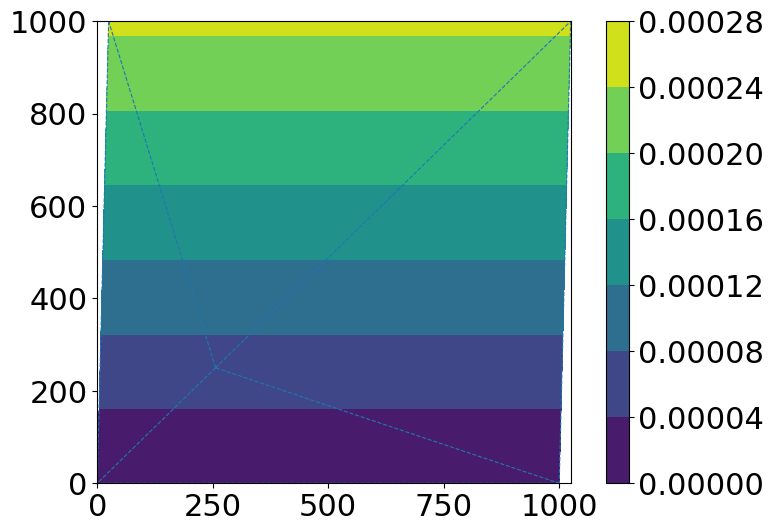

In [16]:
# 4. Résolution
n_nodes = points.shape[0]
u_s = np.zeros(n_nodes * 2)
u_s[libres2] = np.linalg.solve(K[libres2, :][:, libres2], Fs[libres2])

plotMesh(points + u_s.reshape(n_nodes, 2) *100000 , conn, u_s)

In [17]:
# --- Calcul et affichage de la déformation de cisaillement gamma_xy ---

# 1. Reformater le vecteur déplacement
# u_s contient tous les déplacements sous forme plate [ux0, uy0, ux1, uy1, ..., uxn, uyn]
u_s_reshaped = u_s.reshape((n_nodes, 2))  # (n_nodes, 2) : (u_x, u_y)

# 2. Identifier les nœuds du haut et du bas selon la coordonnée y
y = points[:, 1]
eps = 1e-6
nodes_haut = np.where(np.isclose(y, np.max(y), atol=eps))[0]
nodes_bas = np.where(np.isclose(y, np.min(y), atol=eps))[0]

# 3. Extraire les déplacements horizontaux (u_x) des nœuds du haut et du bas
ux_haut = np.mean(u_s_reshaped[nodes_haut, 0])
ux_bas = np.mean(u_s_reshaped[nodes_bas, 0])

# 4. Calculer la hauteur initiale du domaine (entre haut et bas)
H = np.max(y) - np.min(y)

# 5. Calcul de la déformation de cisaillement gamma_xy
# Approximation : gamma_xy ≈ (u_x_haut - u_x_bas) / H
gamma_xy = (ux_haut - ux_bas) / H

# 6. Affichage des résultats
print("Déformation de cisaillement moyenne gamma_xy =", format(gamma_xy, ".6e"), "(adimensionnel)")
print("Déplacement moyen horizontal en haut =", format(ux_haut, ".6e"), "mm")
print("Déplacement moyen horizontal en bas =", format(ux_bas, ".6e"), "mm")
print("Hauteur initiale H =", format(H, ".6e"), "mm")


Déformation de cisaillement moyenne gamma_xy = 2.476190e-07 (adimensionnel)
Déplacement moyen horizontal en haut = 2.476190e-04 mm
Déplacement moyen horizontal en bas = 0.000000e+00 mm
Hauteur initiale H = 1.000000e+03 mm


In [18]:
E = 210000
nu = 0.3
F = 200
tau_xy = 200/(1000*10)                          # tau_xy = F/A
epsilon_xy_exacte = (1+nu)*tau_xy/E             

a2 = np.abs(epsilon_xy_exacte - gamma_xy/2)
EcartRelatif2 = a2/(epsilon_xy_exacte)
print(EcartRelatif2)

if EcartRelatif2 < 1e-14:
    print("La solution est correcte")
else:
    print("La solution n'est pas correcte")

2.1379437370601328e-16
La solution est correcte
